## Value Iteration을 활용한 MDP 실습

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
def print_policy(policy):
    for i in range(4):
        for j in range(4):
            print(f"{policy[(i, j)] or 'X'}", end=" ")
        print()

def print_value(V):
    for i in range(4):
        for j in range(4):
            print(f"{V[(i, j)]:.2f}", end=" ")
        print()
# 상태 전이 확률 및 보상 정의
def get_next_state(state, action):
    i, j = state
    if action == 'up':
        return (max(i - 1, 0), j)
    elif action == 'down':
        return (min(i + 1, 3), j)
    elif action == 'left':
        return (i, max(j - 1, 0))
    elif action == 'right':
        return (i, min(j + 1, 3))

def is_valid(state):
    i, j = state
    return grid[i, j] != 1  # 장애물이 아닌 경우

def get_reward(state):
    i, j = state
    if grid[i, j] == 2:
        return 10  # 목표 지점에 도달하면 보상 10
    else:
        return -1  # 그 외의 경우 보상 -1

def value_iteration(states, actions, gamma=0.9, theta=0.0001, visual_step=None, print_result = True, save_fig = False, save_dir = './DX3_RL/'):
    V = {s: 0 for s in states}  # 초기 가치 함수
    policy = {s: None for s in states}  # 초기 정책
    step = 1
    save_path = os.path.join(save_dir , f'value_iter_k_{0}.jpg')
    if visual_step is not None:
        visualize_value(V, np.array([[0,0,0,0],[0,1,0,1],[0,1,0,0],[0,0,0,2]]), (0,0), step=0, save_fig=save_fig, save_path = save_path)
    
    while True:
        delta = 0
        
        for s in states: # 모든 상
            # print('curent state : ', s)
            if not is_valid(s):
                continue
            v = V[s]
            max_value = float('-inf')
            best_action = None
            for a in actions:
                next_state = get_next_state(s, a)
                if is_valid(next_state):
                    reward = get_reward(next_state)
                    value = reward + gamma * V[next_state]
                    if value > max_value: # 다음 상태될 놈들 중에서 max값을 reward로 받음
                        max_value = value 
                        best_action = a # max value인 것을 action으로 취함
            V[s] = max_value
            policy[s] = best_action # 
            delta = max(delta, abs(v - V[s])) # max value와 현재 value의 차이를 비교 
            
        if visual_step is not None and ((step % visual_step == 0) or (step in range(10) or step == 21)):# and visual_step in range(10):
            save_path = os.path.join(save_dir , f'value_iter_k_{step}.jpg')
            visualize_value(V, np.array([[0,0,0,0],[0,1,0,1],[0,1,0,0],[0,0,0,2]]), (0,0), step, save_fig=save_fig, save_path = save_path)
        
        if step == 21: # 아래 policy iteration과 동일한 evaluation을 했을 때 비교하기 위해서 넣음
            print_policy(policy)
        if delta < theta:
            break
        step += 1
    
    # 결과 출력
    if print_result:
        print("최적 가치 함수:")
        print_value(V)
        
        print("\n최적 정책:")
        print_policy(policy)
        

    return V, policy   

######### 가치 값 시각화 함수
def visualize_value(V, grid_in, agent_position_in, step=None, save_fig = False, save_path = './value_iter.jpg'):
    fig, ax = plt.subplots(figsize=(3,3))
    

    # 1. 각 셀 그리기
    for i in range(grid.shape[0]):
        for j in range(grid.shape[1],):
            cell_value = grid[i, j]
            rect = Rectangle(
                (j - 0.5, i - 0.5),  # (x, y) 좌표
                width=1, height=1,
                facecolor='white' if cell_value == 0 else 'black' if cell_value == 1 else 'green'
            )
            ax.add_patch(rect)
            
            # 2. 가치 값 또는 상태 텍스트 추가
            text = f"{V.get((i, j), 0):.2f}"  # 가치 값 (소수점 2자리)
            # if (i, j) == agent_position:
            #     text = "A"  # 에이전트
            # elif cell_value == 1:
            #     text = "X"  # 장애물
            # elif cell_value == 2:
            #     text = "G"  # 목표 지점
            # else:
                # text = f"{V.get((i, j), 0):.2f}"  # 가치 값 (소수점 2자리)

            # 텍스트 위치 및 스타일 설정
            text_obj = ax.text(
                j, i, text,
                ha='center', va='center',
                color='black' if cell_value == 0 else 'white',                
                fontsize=10
            )

    # 3. 격자선 및 축 설정
    ax.set_xticks(np.arange(-0.5, grid.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, grid.shape[0], 1), minor=True)
    ax.grid(which='minor', color='gray', linestyle='-', linewidth=1)
    ax.tick_params(which='minor', size=0)
    ax.set_xticks([])
    ax.set_yticks([])

    # 4. 제목 추가 (step 표시)
    if step is not None:
        plt.title(f"Value Iteration : k {step}", fontsize=12)

    plt.tight_layout()
    plt.gca().invert_yaxis()
    if save_fig:
        plt.savefig(save_path)
        # print('save has done')
    plt.show()
    
    
########### grid시각화 함수

def visualize_grid_with_agent(grid_in, agent_position_in):
    grid = np.flipud(grid_in)
    agent_position = (3- agent_position_in[0], agent_position_in[1])
    # 색상 매핑
    color_map = {
        0: 'white',      # 빈 공간
        1: 'black',      # 장애물
        2: 'green'       # 목표 지점
    }

    fig, ax = plt.subplots()
    
    # 1. 각 셀 그리기
    for i in range(grid.shape[0]):  # 행 (y축)
        for j in range(grid.shape[1]):  # 열 (x축)
            cell_value = grid[i, j]
            rect = Rectangle(
                (j - 0.5, i - 0.5),  # (x, y) 좌표
                width=1, height=1,
                facecolor=color_map[cell_value]
            )
            ax.add_patch(rect)

    # 2. 에이전트 위치 표시
    agent_rect = Rectangle(
        (agent_position[1] - 0.5, agent_position[0] - 0.5),
        width=1, height=1,
        facecolor='red'
    )
    ax.add_patch(agent_rect)

    # 3. 격자선 및 축 설정
    ax.set_xticks(np.arange(-0.5, grid.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, grid.shape[0], 1), minor=True)
    ax.grid(which='minor', color='gray', linestyle='-', linewidth=2)
    ax.tick_params(which='minor', size=0)
    ax.set_xticks([])
    ax.set_yticks([])

    plt.tight_layout()
    plt.show()

#### Policy 시각화

def visualize_policy(policy, save_path = None, title = None):
    arrow_map = {
        'right': (0, 1),   # 오른쪽
        'left': (0, -1),  # 왼쪽
        'up': (-1, 0),  # 위
        'down': (1, 0),   # 아래
        None: (0, 0)    # 정의되지 않음
    }
    # 그리드 크기
    grid_size = (4, 4)

    # 화살표 크기 (비율 조정)
    arrow_size = 0.3

    # 시각화
    fig, ax = plt.subplots(figsize=(3, 3))
    ax.set_xlim(-0.5, grid_size[1] - 0.5)
    ax.set_ylim(-0.5, grid_size[0] - 0.5)
    ax.set_xticks(np.arange(grid_size[1]))
    ax.set_yticks(np.arange(grid_size[0]))
    ax.grid(True)
    ax.set_xticks([])
    ax.set_yticks([])

    color_map = {
            0: 'white',      # 빈 공간
            1: 'black',      # 장애물
            2: 'green'       # 목표 지점
        }

    # 1. 각 셀 그리기
    for i in range(grid.shape[0]):  # 행 (y축)
        for j in range(grid.shape[1]):  # 열 (x축)
            cell_value = grid[i, j]
            rect = Rectangle(
                (j - 0.5, i - 0.5),  # (x, y) 좌표
                width=1, height=1,
                facecolor=color_map[cell_value]
            )
            ax.add_patch(rect)

     # 2. 에이전트 위치 표시
        agent_rect = Rectangle(
            (agent_position[1] - 0.5, agent_position[0] - 0.5),
            width=1, height=1,
            facecolor='red'
        )
        ax.add_patch(agent_rect)

        # 3. 격자선 및 축 설정
        ax.set_xticks(np.arange(-0.5, grid.shape[1], 1), minor=True)
        ax.set_yticks(np.arange(-0.5, grid.shape[0], 1), minor=True)
        ax.grid(which='minor', color='gray', linestyle='-', linewidth=2)
        ax.tick_params(which='minor', size=0)
        ax.set_xticks([])
        ax.set_yticks([])

    # 화살표 그리기
    for i in range(grid_size[0]):
        for j in range(grid_size[1]):

            direction = policy.get((i, j), 'X')
            # print(i, j, direction)
            dx, dy = arrow_map[direction]
            ax.arrow(
                j, i,
                dy * arrow_size, dx * arrow_size,
                head_width=0.1, head_length=0.1,
                fc='blue', ec='blue'
            )

    plt.gca().invert_yaxis()  # y축 반전 (위쪽이 0)
    plt.tight_layout
    if title is not None:
        plt.title(title, fontsize=12, y=1)
    if save_path is not None:
        plt.savefig(save_path)    
    plt.show()

### Grid World 환경 정의

[(0, 0), (0, 1), (0, 2), (0, 3), (1, 0), (1, 1), (1, 2), (1, 3), (2, 0), (2, 1), (2, 2), (2, 3), (3, 0), (3, 1), (3, 2), (3, 3)]


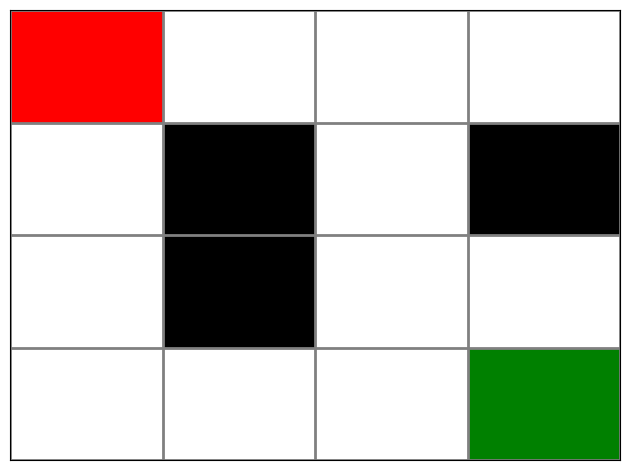

In [3]:
# Grid World 환경 정의
# 0: 빈 공간, 1: 장애물, 2: 목표 지점
grid = np.array([
    [0, 0, 0, 0],
    [0, 1, 0, 1],
    [0, 1, 0, 0],
    [0, 0, 0, 2]
])

# 상태와 행동 정의
states = [(i, j) for i in range(4) for j in range(4)]
print(states)
actions = ['up', 'down', 'left', 'right']

# 에이전트 초기 위치
agent_position = (0, 0) # 행, 열 , (0,0)
visualize_grid_with_agent(grid, agent_position)

## Value Iteration 실행

In [201]:
# Value Iteration 실행
V, policy = value_iteration(states, actions, print_result=True, visual_step=None)

down right down left 
down X down X 
down X down down 
right right right down 
최적 가치 함수:
54.95 62.17 70.19 62.17 
62.17 0.00 79.10 0.00 
70.19 0.00 89.00 100.00 
79.10 89.00 100.00 100.00 

최적 정책:
down right down left 
down X down X 
down X down down 
right right right down 


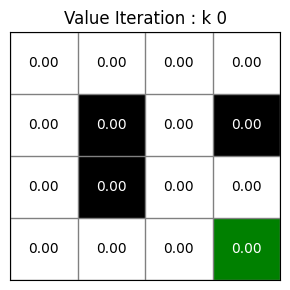

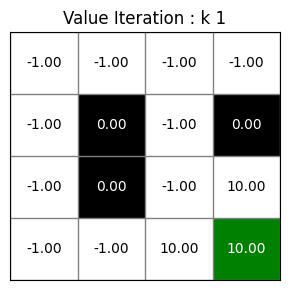

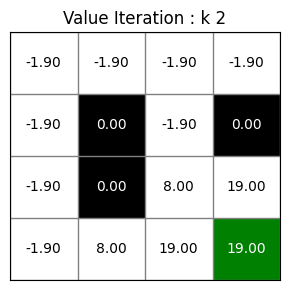

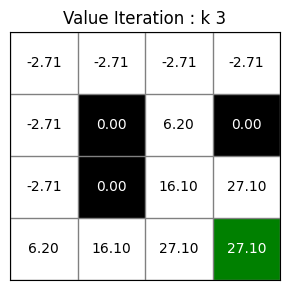

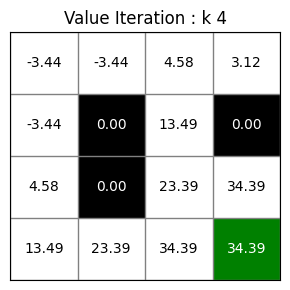

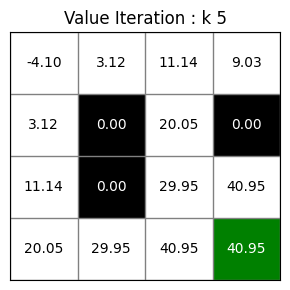

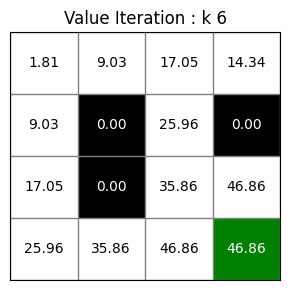

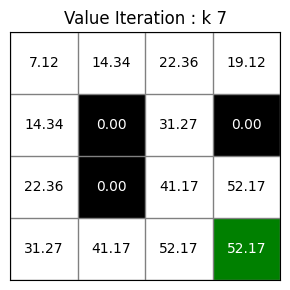

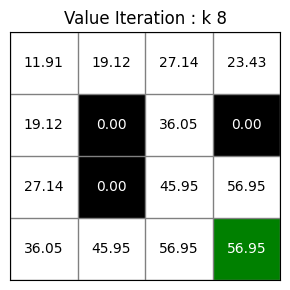

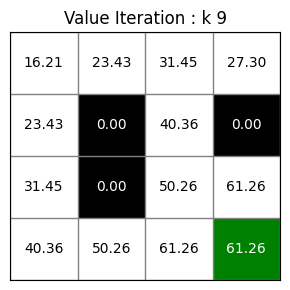

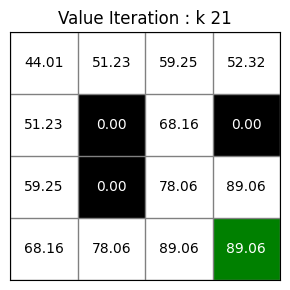

down right down left 
down X down X 
down X down down 
right right right down 


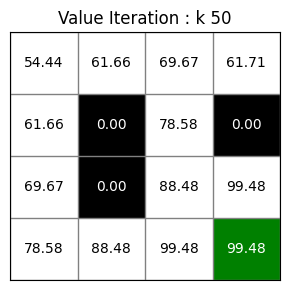

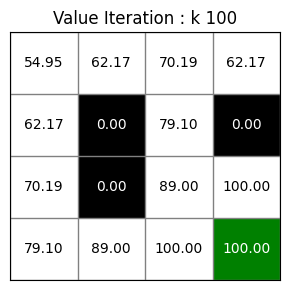

최적 가치 함수:
54.95 62.17 70.19 62.17 
62.17 0.00 79.10 0.00 
70.19 0.00 89.00 100.00 
79.10 89.00 100.00 100.00 

최적 정책:
down right down left 
down X down X 
down X down down 
right right right down 


In [202]:
V, policy = value_iteration(states, actions, print_result=True, visual_step=50, save_fig=True)

## Policy visualization

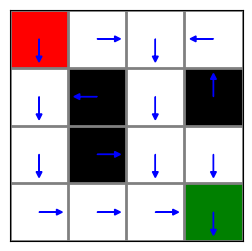

In [143]:
visualize_policy(policy)

## Value Iteration vs Policy Iteration

| 특징              | Value Iteration                                                                 | Policy Iteration                                                                 |
|-------------------|---------------------------------------------------------------------------------|---------------------------------------------------------------------------------|
| 목표              | 최적 가치 함수 \( V^* \)를 찾고, 이를 통해 최적 정책 \( \pi^* \)를 유도         | 최적 정책 \( \pi^* \)를 직접 찾음                                               |
| 업데이트 방식     | 모든 상태에 대해 가치 함수를 반복적으로 업데이트                                | 1. 정책 평가 (Policy Evaluation): 현재 정책에 따라 가치 함수 업데이트<br>2. 정책 개선 (Policy Improvement): 새로운 정책 생성 |
| 상태 방문 방식    | 모든 상태를 방문하여 가치 함수를 업데이트                                        | 정책에 따라 상태를 방문하며 가치 함수를 업데이트                                |
| 수렴 조건         | 가치 함수의 변화량(델타)이 임계값보다 작아질 때까지 반복                          | 정책이 더 이상 개선되지 않을 때까지 반복                                        |
| 복잡도            | 일반적으로 더 많은 반복이 필요할 수 있음                                        | 일반적으로 더 적은 반복이 필요할 수 있음        

## Policy Iteration

In [193]:
######### 가치 값 시각화 함수
def print_policy(policy):
    for i in range(4):
        for j in range(4):
            print(f"{policy[(i, j)] or 'X'}", end=" ")
        print()

def print_value(V):
    for i in range(4):
        for j in range(4):
            print(f"{V[(i, j)]:.2f}", end=" ")
        print()
    
    
def visualize_value2(V, grid_in, agent_position_in, step=None, save_fig=False, save_path='./value_iter.jpg', ax=None,):
    if ax is None:
        fig, ax = plt.subplots(figsize=(3, 3))  # ax가 없으면 새로 생성
    else:
        fig = ax.figure  # ax가 있으면 기존 figure 사용

    # 1. 각 셀 그리기
    for i in range(grid_in.shape[0]):
        for j in range(grid_in.shape[1]):
            cell_value = grid_in[i, j]
            rect = Rectangle(
                (j - 0.5, i - 0.5),  # (x, y) 좌표
                width=1, height=1,
                facecolor='white' if cell_value == 0 else 'black' if cell_value == 1 else 'green'
            )
            ax.add_patch(rect)

            # 2. 가치 값 또는 상태 텍스트 추가
            text = f"{V.get((i, j), 0):.2f}"  # 가치 값 (소수점 2자리)
            text_obj = ax.text(
                j, i, text,
                ha='center', va='center',
                color='black' if cell_value == 0 else 'white',                
                fontsize=10
            )

    # 3. 격자선 및 축 설정
    ax.set_xticks(np.arange(-0.5, grid_in.shape[1], 1), minor=True)
    ax.set_yticks(np.arange(-0.5, grid_in.shape[0], 1), minor=True)
    ax.grid(which='minor', color='gray', linestyle='-', linewidth=1)
    ax.tick_params(which='minor', size=0)
    ax.set_xticks([])
    ax.set_yticks([])

    # 4. 제목 추가 (step 표시)
    if step is not None:
        # plt.title(f"Policy Iteration : k = {step}", fontsize=12)
        ax.set_title(f" eval_num = {step}", fontsize=12)

    # ax.tight_layout()
    # plt.gca().invert_yaxis()
    ax.invert_yaxis()
    if save_fig:
        plt.savefig(save_path)
    if ax is None:
        plt.show()
    else:
        return ax  # ax 반환

def visualize_policy_eval(V_history, grid_in, agent_position_in, step = None, save_fig=False, save_path='./policy_eval.jpg'):
    """Policy Evaluation 단계별 가치 함수를 가로로 N개 플롯"""
    num_col = len(V_history)
    fig, axes = plt.subplots(1, num_col, figsize=(20, 3))  # 1행 10열 플롯
    for i in range(num_col):
        ax = axes[i] # if i < 10 else None  # 10개까지만 처리
        if ax is None:
            continue
        # 각 단계별로 가상의 가치 함수 생성 (실제 구현시 V_history[i] 사용)
        sample_V = V_history[i] #if i < len(V_history) else V_history[-1]
        ax = visualize_value2(sample_V, grid_in, agent_position_in, step=i+1, ax=ax)
    
    fig.suptitle(f"Policy Iterations : k = {step}", fontsize=14, y=1)
    plt.tight_layout()  # 레이아웃 조정
    # plt.gca().invert_yaxis()
    if save_fig:
        plt.savefig(save_path)
    plt.show()
    plt.close()


def policy_iteration(states, actions, gamma=0.9, max_eval_num=10, visual_step=None, print_result=True, save_fig=False, save_dir='./DX3_RL/', init_policy = None):
    # 초기 정책 (임의의 정책으로 초기화)
    if init_policy is None:
        policy = {s: np.random.choice(actions) for s in states}        
    else:
        policy = {s: a for s, a in zip(states, init_policy)}        
    V = {s: 0 for s in states}  # 초기 가치 함수
    

    step = 0
    save_path = os.path.join(save_dir, f'policy_iter_k_{0}.jpg')
    # if visual_step is not None:
    #     visualize_value(V, np.array([[0,0,0,0],[0,1,0,1],[0,1,0,0],[0,0,0,2]]), (0,0), step=0, save_fig=save_fig, save_path=save_path)

    while True:
        # Policy Evaluation (고정된 반복 횟수만큼만 수행)
        V_history =[]  # Policy Evaluation 단계별 V 저장
        print('\n', '-'*200, '\n', f'[Iter k = {step+1}] ]  Current Policy')
        print_policy(policy)
        visualize_policy(policy, save_path = f'DX3_RL/policy_iteration/current_policy_k_{step+1}.jpg', title = f'Current Policy : k = {step+1}')
        
        for step_eval in range(max_eval_num):
            for s in states:
                if not is_valid(s):
                    continue
                v = V[s]
                a = policy[s]  # 현재 정책에 따라 행동 선택
                next_state = get_next_state(s, a)
                if is_valid(next_state):
                    reward = get_reward(next_state)
                    V[s] = reward + gamma * V[next_state]  # 정책 고정 → max 없음
            V_history.append({s: V[s] for s in states})  # 현재 V 저장
        
        # 시각화
        if visual_step is not None and ((step % visual_step == 0) or (step in range(10))):
            # print('visualize policy evaluation')
            save_path = os.path.join(save_dir, f'policy_iter_k_{step+1}_eval_steps.jpg')
            visualize_policy_eval(V_history, np.array([[0,0,0,0],[0,1,0,1],[0,1,0,0],[0,0,0,2]]), (0,0), step = step+1, save_fig=save_fig, save_path=save_path)

        # Policy Improvement
        policy_stable = True
        for s in states:
            if not is_valid(s):
                continue
            old_action = policy[s]
            max_value = float('-inf')
            best_action = None
            for a in actions: # 현재 상태에서 모든 action에 대해 가치 함수를 평가
                next_state = get_next_state(s, a)
                if is_valid(next_state):
                    reward = get_reward(next_state)
                    value = reward + gamma * V[next_state]
                    # print(f'action={a}, reward = {reward}, next_state = {next_state}, next_state_value = {V[next_state]}, new_value = {value}')
                    if value > max_value:
                        max_value = value
                        best_action = a
            # input('press enter')
            policy[s] = best_action
            if old_action != best_action: # 모든 상태에서 best정책과 같아져야 policy_stable이 True가 됨
                policy_stable = False

        
        print(f'[Iter k = {step+1}] ] Is policy stable? {policy_stable}, Improved Policy')
        print_policy(policy)
        visualize_policy(policy, save_path = f'DX3_RL/policy_iteration/improved_policy_k_{step+1}.jpg', title = f'Improved Policy : k = {step+1}')
        if policy_stable:
            print('Policy is stable')
            break
        step += 1

    # 결과 출력
    if print_result:
        print("최적 가치 함수:")
        print_value(V)

        print("\n최적 정책:")
        print_policy(policy)

    return V, policy

In [186]:
init_policy = ['up', 'right', 'right', 'left', 
            'down', 'up', 'left', 'left', 
            'up', 'up', 'down', 'down', 
            'down', 'right', 'down', 'left']


 -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- 
 [Iter k = 1] ]  Current Policy
up right right left 
down up left left 
up up down down 
down right down left 


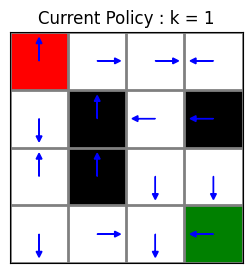

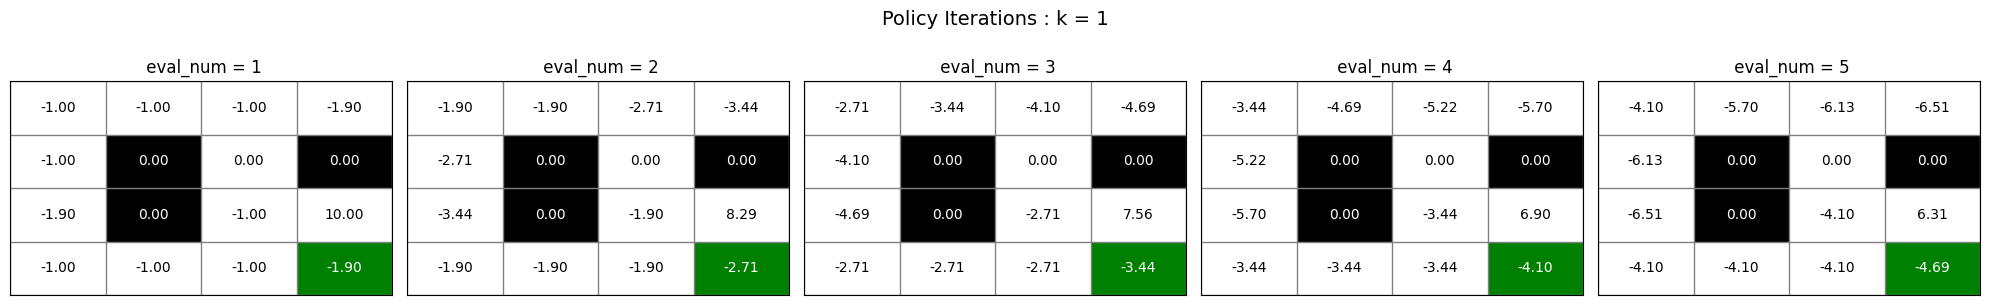

[Iter k = 1] ] Is policy stable? False, Improved Policy
up left down left 
up up down left 
down up right down 
down down right down 


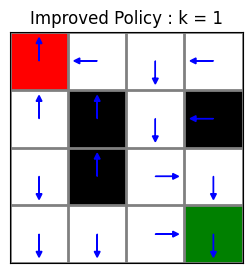


 -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- 
 [Iter k = 2] ]  Current Policy
up left down left 
up up down left 
down up right down 
down down right down 


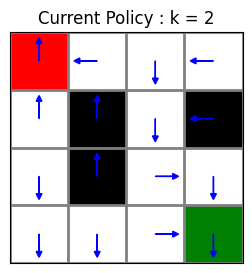

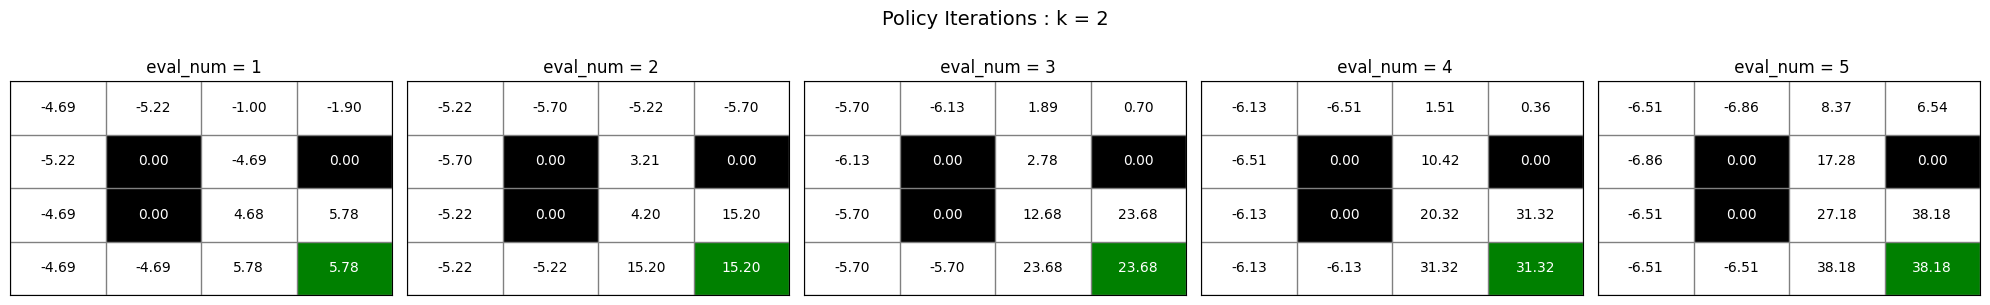

[Iter k = 2] ] Is policy stable? False, Improved Policy
up right down left 
up up down left 
down up down down 
up right right down 


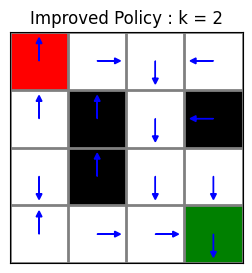


 -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- 
 [Iter k = 3] ]  Current Policy
up right down left 
up up down left 
down up down down 
up right right down 


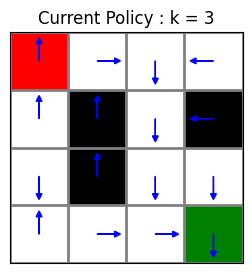

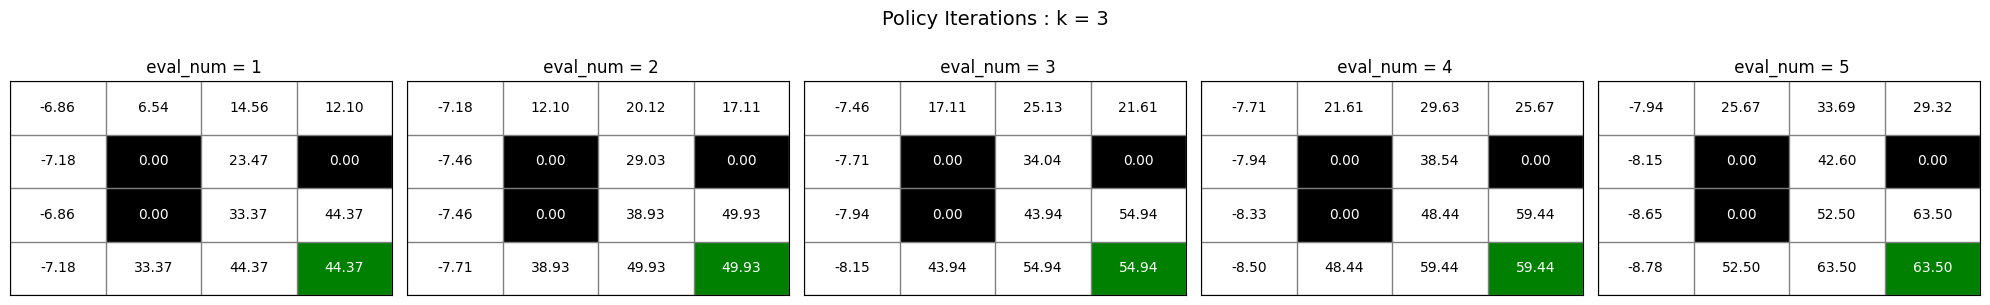

[Iter k = 3] ] Is policy stable? False, Improved Policy
right right down left 
up up down left 
up up down down 
right right right down 


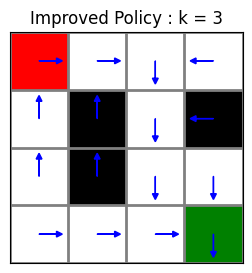


 -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- 
 [Iter k = 4] ]  Current Policy
right right down left 
up up down left 
up up down down 
right right right down 


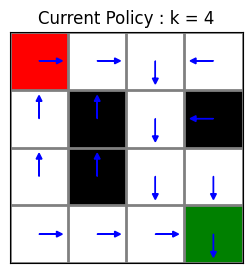

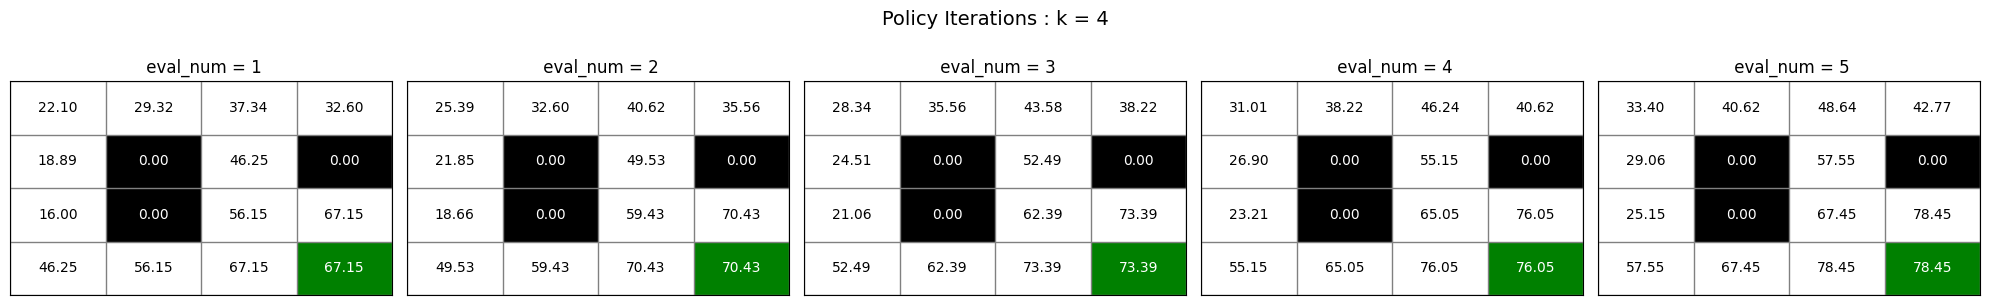

[Iter k = 4] ] Is policy stable? False, Improved Policy
right right down left 
up up down left 
down up down down 
right right right down 


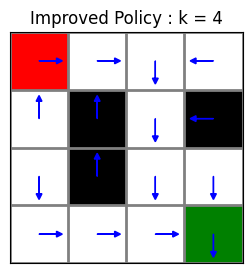


 -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- 
 [Iter k = 5] ]  Current Policy
right right down left 
up up down left 
down up down down 
right right right down 


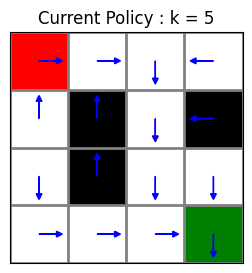

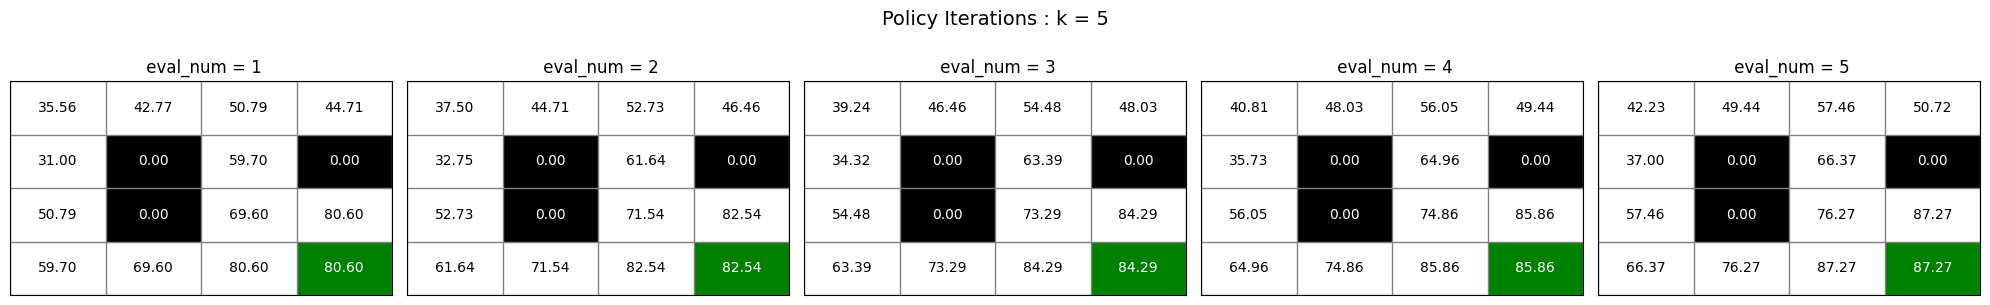

[Iter k = 5] ] Is policy stable? False, Improved Policy
right right down left 
down up down left 
down up down down 
right right right down 


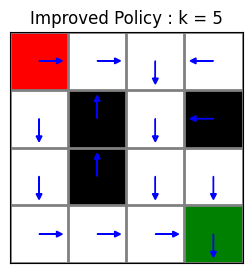


 -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- 
 [Iter k = 6] ]  Current Policy
right right down left 
down up down left 
down up down down 
right right right down 


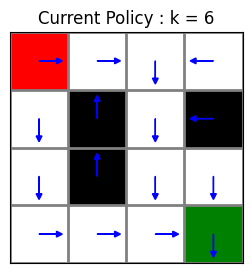

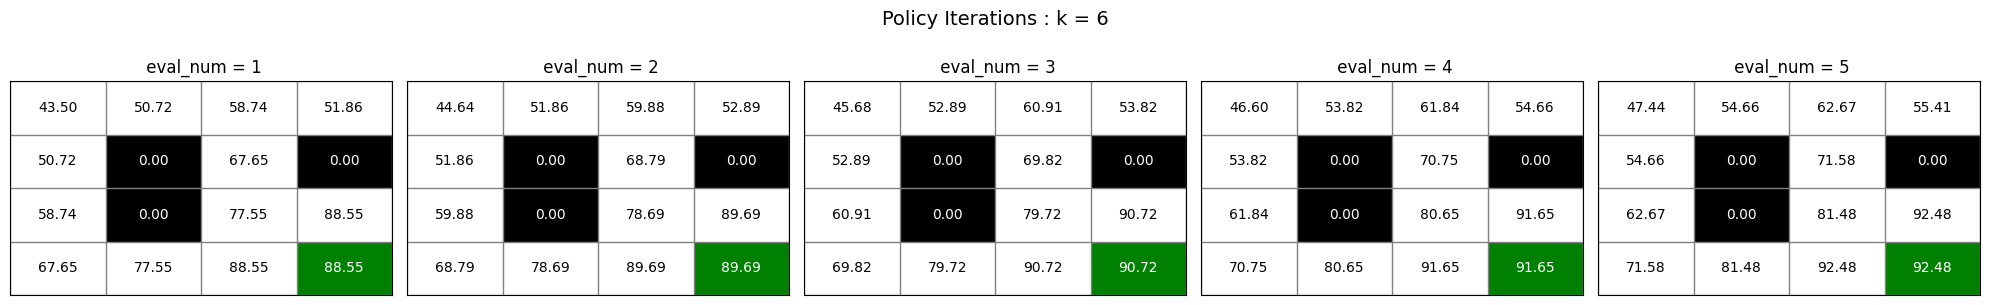

[Iter k = 6] ] Is policy stable? False, Improved Policy
down right down left 
down up down left 
down up down down 
right right right down 


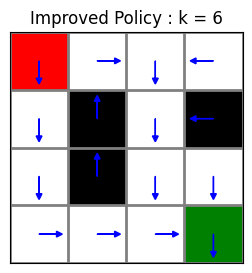


 -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- 
 [Iter k = 7] ]  Current Policy
down right down left 
down up down left 
down up down down 
right right right down 


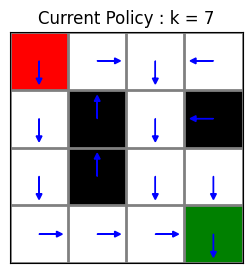

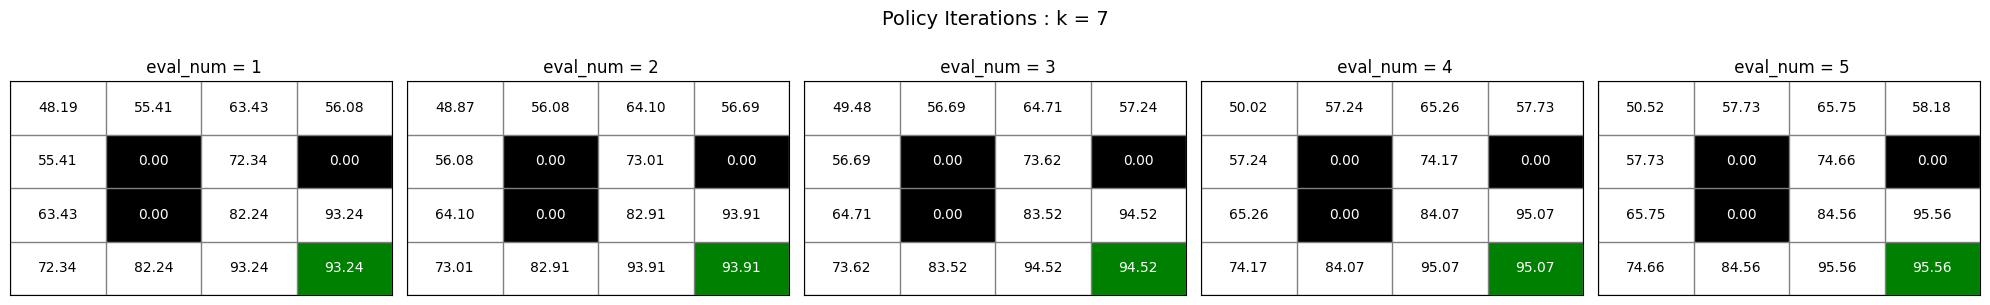

[Iter k = 7] ] Is policy stable? True, Improved Policy
down right down left 
down up down left 
down up down down 
right right right down 


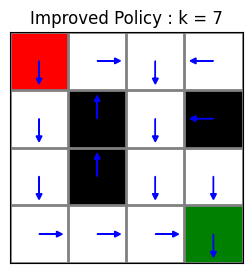

Policy is stable
최적 가치 함수:
50.52 57.73 65.75 58.18 
57.73 0.00 74.66 0.00 
65.75 0.00 84.56 95.56 
74.66 84.56 95.56 95.56 

최적 정책:
down right down left 
down up down left 
down up down down 
right right right down 


In [187]:
V, policy = policy_iteration(states, actions, gamma=0.9, max_eval_num=5, visual_step=10, print_result=True, save_fig=True, save_dir='./DX3_RL/policy_iteration', init_policy = init_policy)

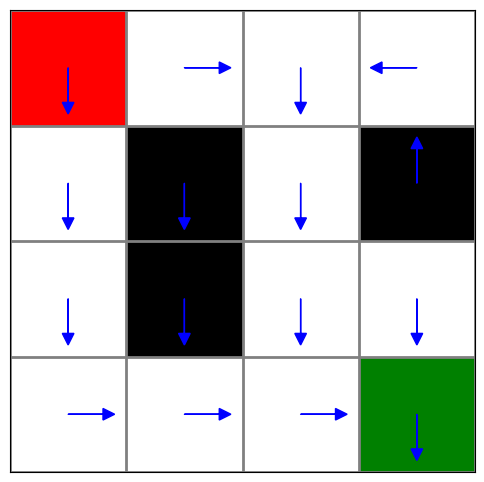

In [106]:
visualize_policy(policy)


 -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- 
 [Iter k = 1] ]  Current Policy
up right right left 
down up left left 
up up down down 
down right down left 


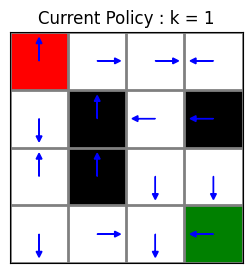

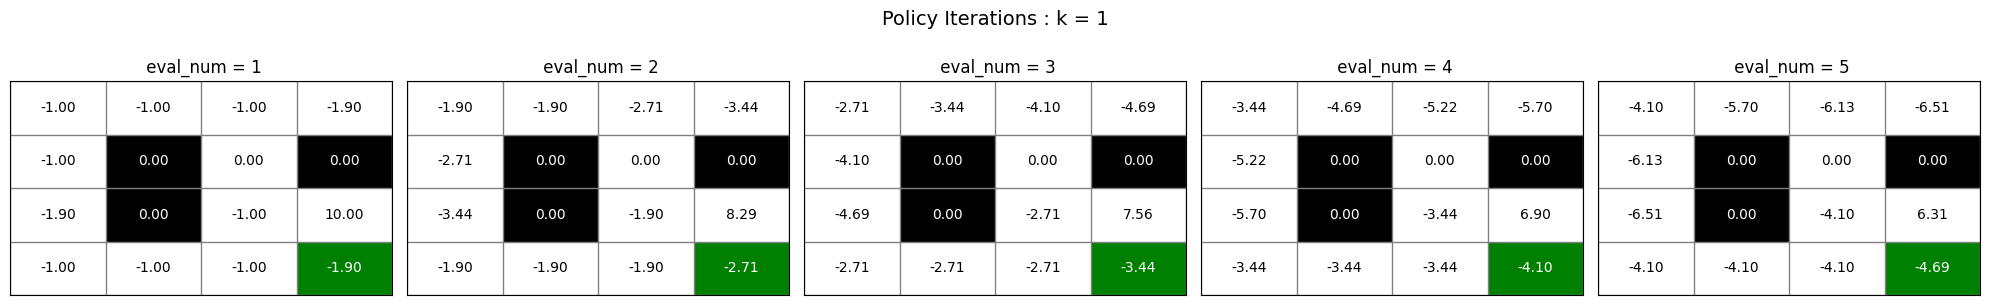

[Iter k = 1] ] Is policy stable? False, Improved Policy
up left down left 
up up down left 
down up right down 
down down right down 


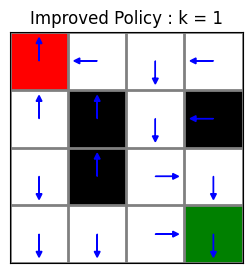


 -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- 
 [Iter k = 2] ]  Current Policy
up left down left 
up up down left 
down up right down 
down down right down 


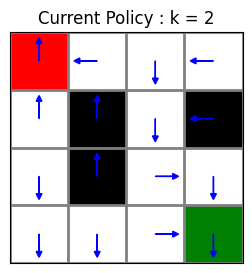

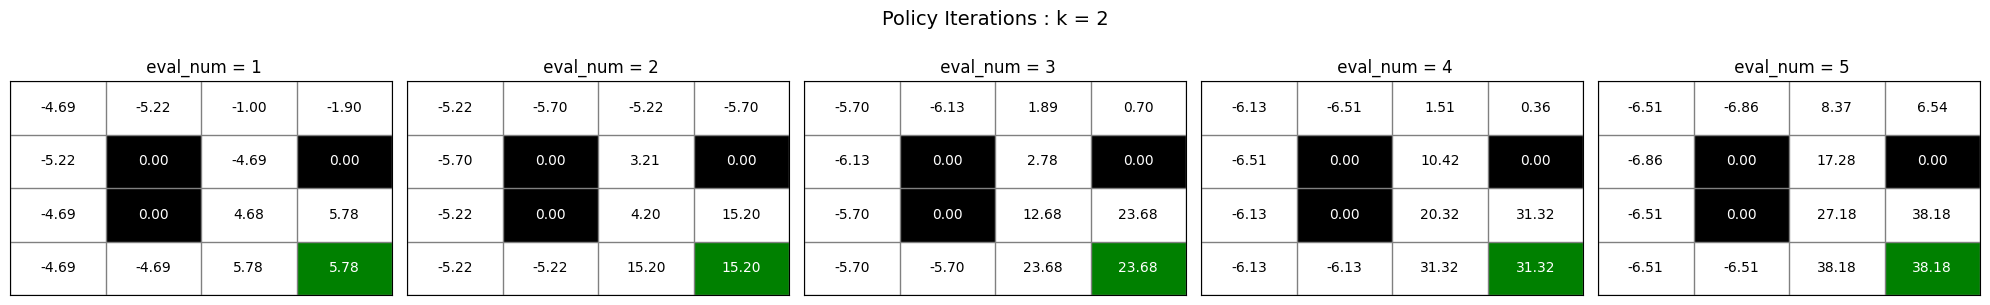

[Iter k = 2] ] Is policy stable? False, Improved Policy
up right down left 
up up down left 
down up down down 
up right right down 


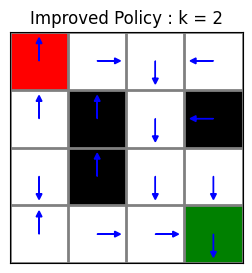


 -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- 
 [Iter k = 3] ]  Current Policy
up right down left 
up up down left 
down up down down 
up right right down 


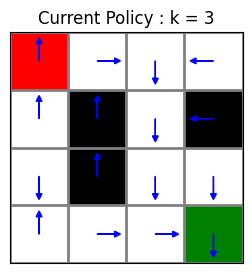

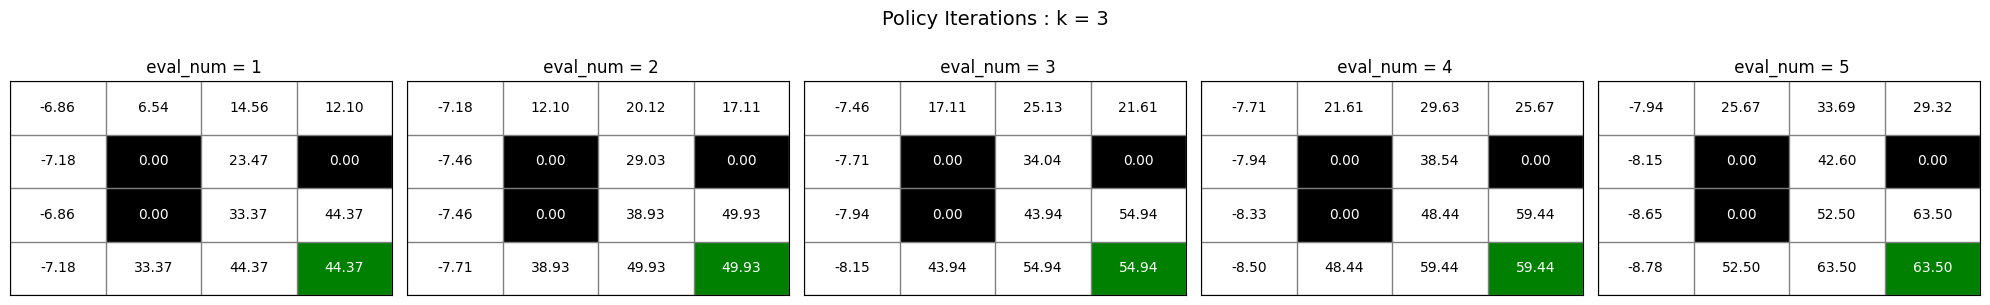

[Iter k = 3] ] Is policy stable? False, Improved Policy
right right down left 
up up down left 
up up down down 
right right right down 


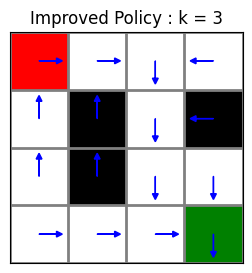


 -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- 
 [Iter k = 4] ]  Current Policy
right right down left 
up up down left 
up up down down 
right right right down 


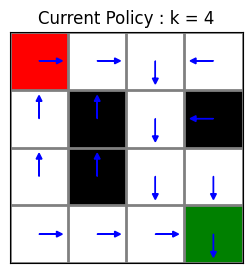

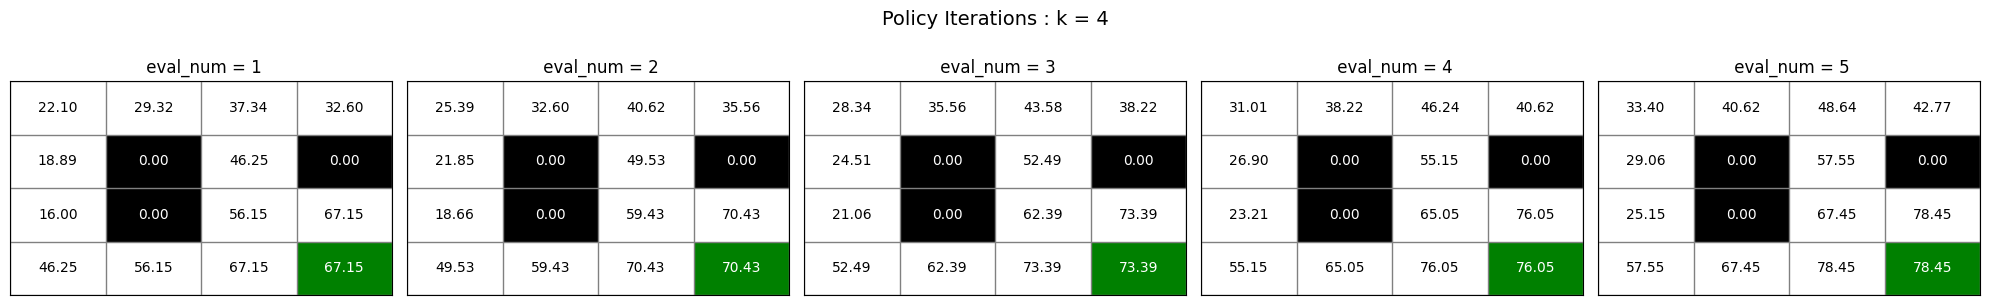

[Iter k = 4] ] Is policy stable? False, Improved Policy
right right down left 
up up down left 
down up down down 
right right right down 


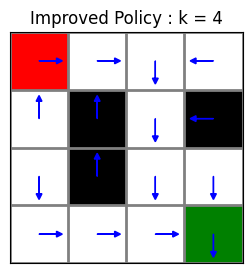


 -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- 
 [Iter k = 5] ]  Current Policy
right right down left 
up up down left 
down up down down 
right right right down 


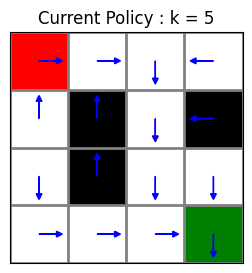

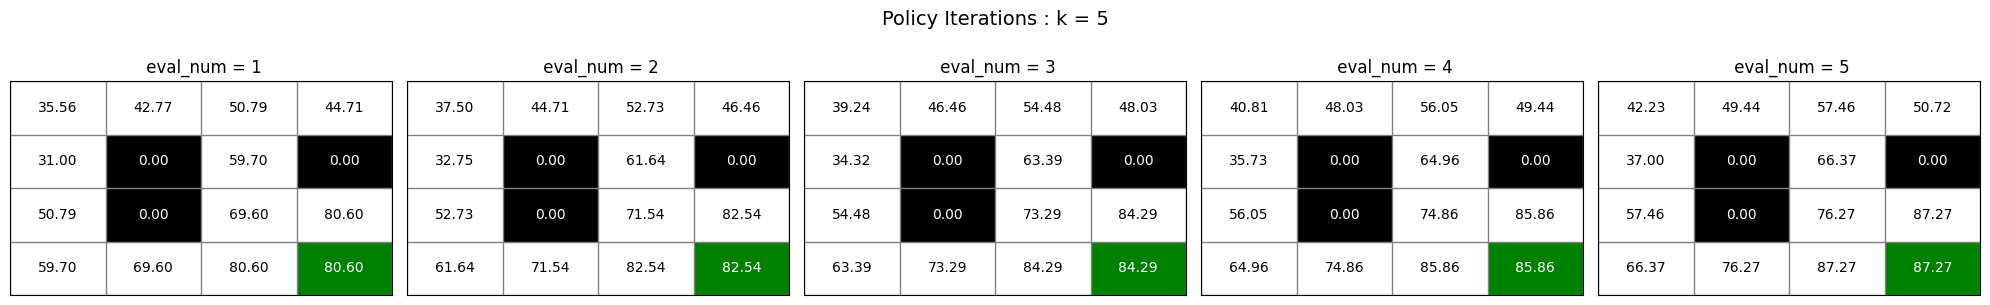

[Iter k = 5] ] Is policy stable? False, Improved Policy
right right down left 
down up down left 
down up down down 
right right right down 


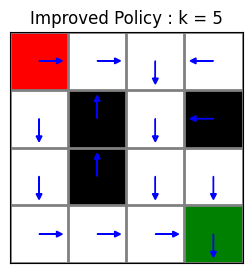


 -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- 
 [Iter k = 6] ]  Current Policy
right right down left 
down up down left 
down up down down 
right right right down 


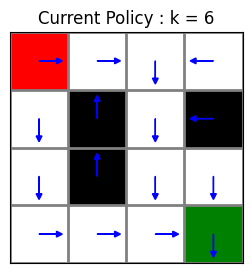

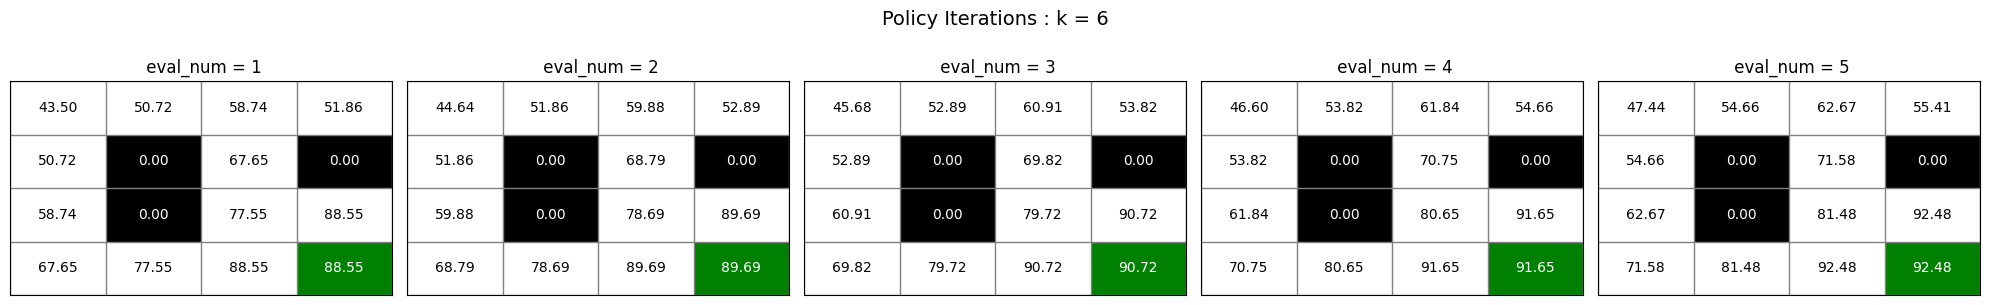

[Iter k = 6] ] Is policy stable? False, Improved Policy
down right down left 
down up down left 
down up down down 
right right right down 


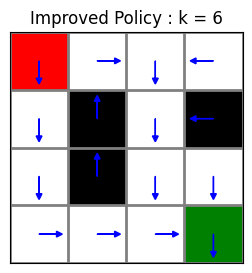


 -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- 
 [Iter k = 7] ]  Current Policy
down right down left 
down up down left 
down up down down 
right right right down 


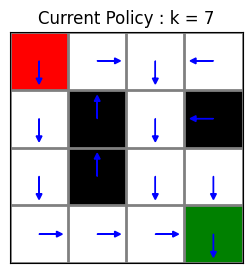

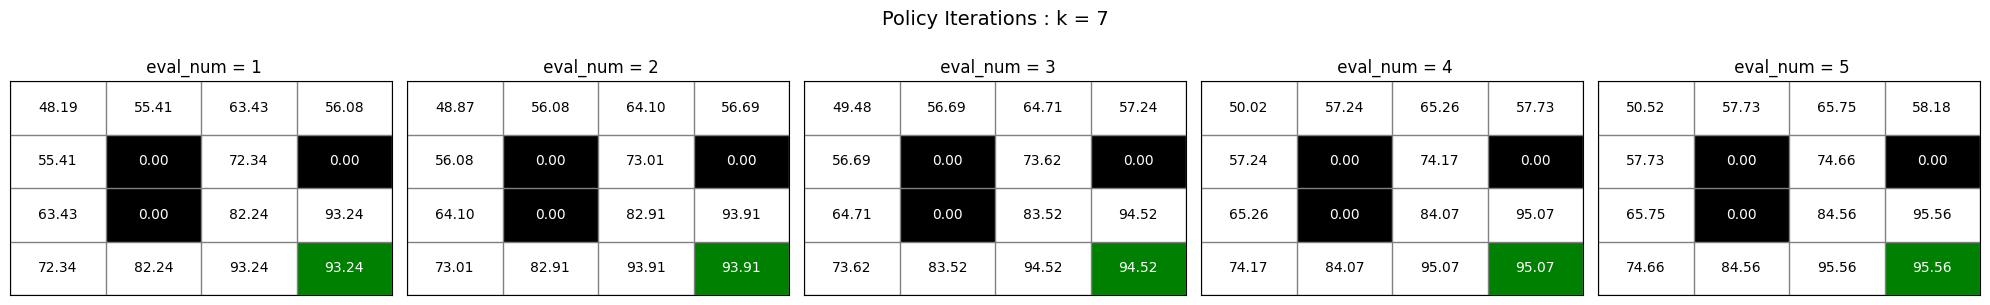

[Iter k = 7] ] Is policy stable? True, Improved Policy
down right down left 
down up down left 
down up down down 
right right right down 


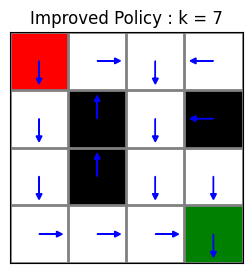

Policy is stable
최적 가치 함수:
50.52 57.73 65.75 58.18 
57.73 0.00 74.66 0.00 
65.75 0.00 84.56 95.56 
74.66 84.56 95.56 95.56 

최적 정책:
down right down left 
down up down left 
down up down down 
right right right down 


In [203]:
V, policy = policy_iteration(states, actions, gamma=0.9, max_eval_num=5, visual_step=10, print_result=True, save_fig=False, save_dir='./DX3_RL/', init_policy = init_policy)